
# Bridging SEALS and Dispersive Fourier Transform

**A research bridge notebook** connecting two pieces of Jalali-lab machinery already validated
separately in this repository: `projects/seals/` (spectrally encoded angular light scattering)
and `dgs/dispersive_fourier.py` (time-stretch dispersive Fourier transform, TS-DFT). Nothing
physical is reinvented here — every equation is used via the repo's own existing, tested code.

**Core question:** the SEALS paper's own Sec. 4 proposes replacing its optical spectrum
analyzer (OSA) with TS-DFT for high-throughput operation, but never implements it. Does the
lab's actual TS-DFT code (`dgs/dispersive_fourier.py`), run on SEALS's own validated Mie
scattering output, actually reproduce that spectrum through the far-field time-stretch mapping?


In [1]:

import sys
sys.path.insert(0, '.')                                    # projects/seals/ itself
sys.path.insert(0, str(__import__('pathlib').Path('.').resolve().parents[1]))  # repo root, for dgs

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display

from inverse import measurement
from inverse import _seals_physics as physics
from dgs import dispersive_fourier as tsdft

sp.init_printing(use_latex='mathjax')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

def show(label, expr):
    print(label)
    display(expr)

print('ready')


ready



---
# Part 1 — Two Things Called "Dispersion" in This Codebase

**SEALS's dispersion** (`SEALS.m`, `_seals_physics.seals()`, validated against `test1.mat`
elsewhere in this repo) is *angular/spatial* dispersion: a pair of diffraction gratings sends
different wavelengths to different **angles in space**. It is a static, geometric mapping
$\lambda\to\theta$ — nothing propagates in time within that model at all.

**Time-stretch dispersive Fourier transform's dispersion** (`dgs/dispersive_fourier.py`) is
*temporal/group-velocity* dispersion (GVD): a single pulse's frequency components travel through
a fiber at different speeds, so they arrive at the far end at different **times**. A single
photodetector, sampled in time, then reveals the input spectrum.

These are genuinely different physical mechanisms. The SEALS paper connects them only as a
*proposal*: replace its OSA (which reads a spectrum directly) with a TS-DFT stage (which reads a
spectrum by watching it unfold in time), for higher frame rate. The original MATLAB never
implements this — Part 4 below is what happens if you actually try it, using this lab's real
TS-DFT code on SEALS's real Mie output.



**Feynman check:** if SEALS's grating already gives you an angle for every wavelength, why does
the paper still want to replace the OSA at all? (Hint: re-read Part 3 of the paper's abstract —
what does the OSA actually still have to do, even after the grating has done the spatial part?)



---
# Part 2 — The Two Equations, Side by Side

**SEALS mapping** (recap, already validated):
$$
y(\lambda) = \frac{D}{6}\frac{\tan\Delta}{1+\tan\Delta\tan\alpha}, \quad
\Delta = \alpha - \arcsin\!\left(\frac{\lambda}{d}-\sin\alpha\right), \quad
\theta(\lambda) = \arctan\!\left[\frac{2}{P}(y-y_c+d_{corr})\tan(\arcsin NA)\right]
$$

**GVD transfer function** (`tsdft.gvd_transfer_function`, all-pass, pure phase):
$$
H(\omega) = \exp\!\left(i\,\frac{\beta_2 L}{2}\,\omega^2\right), \qquad |H(\omega)|=1
$$

**Far-field time-stretch mapping** (`tsdft.dispersive_fourier_transform`, valid when
$|\beta_2 L|\gg T_0^2$):
$$
I_{out}(t) \approx |E(\omega)|^2 \Big|_{\omega = t/(\beta_2 L)}
$$

The SEALS equation has no time variable; the TS-DFT equation has no scattering angle. Bridging
them (Part 4) means: take a *spectrum* SEALS already computes (intensity vs. $\lambda$, via its
$\theta(\lambda)$ mapping and the Mie model), and ask whether feeding a pulse with that spectrum
through the *second* equation reproduces it.



---
# Part 3 — Reconciling Two Dispersion Conventions

This repository actually has *two* numeric conventions for the same quadratic-phase idea:

- **Physical SI units** (`dgs.dispersive_fourier.gvd_transfer_function`):
  $H(\omega)=\exp(i\,\beta_2 L\,\omega^2/2)$, with $\beta_2$ in s$^2$/m, $L$ in m, $\omega$ in
  rad/s relative to the carrier.
- **Normalized/dimensionless** (`dgs.gs_core.disperse`, and this project's own
  `inverse/dispersion.py`): $H(\nu)=\exp(i\pi D\nu^2)$, with $\nu=$ `fftfreq(N)` $\in[-0.5,0.5)$
  dimensionless, and $D$ a single dimensionless dispersion strength.

Equate the two quadratic-phase exponents for a signal of $N$ samples spaced $\Delta t$ apart
(so $\omega = 2\pi\nu/\Delta t$) to derive $D$ in terms of the physical $\beta_2, L$.


In [2]:

beta2_s, L_s, dt_s, nu_s, D_s, omega_s = sp.symbols(
    'beta2 L Delta_t nu D omega', real=True, positive=True)

# physical phase, expressed in terms of normalized nu via omega = 2*pi*nu/Delta_t
phase_physical = beta2_s * L_s * (2*sp.pi*nu_s/dt_s)**2 / 2

# normalized-convention phase
phase_normalized = sp.pi * D_s * nu_s**2

D_solution = sp.solve(sp.Eq(phase_physical, phase_normalized), D_s)[0]
show('D (dimensionless) in terms of physical beta2, L, sample spacing:', sp.simplify(D_solution))


D (dimensionless) in terms of physical beta2, L, sample spacing:


2⋅π⋅L⋅β₂
────────
    2   
  Δₜ    

In [3]:

D_numeric = sp.lambdify((beta2_s, L_s, dt_s), D_solution, 'numpy')

# a representative case: standard single-mode fiber, 5 km, 1 ns sample spacing
beta2_example = -25e-27   # s^2/m  (-25 ps^2/km, typical SMF anomalous-ish magnitude)
L_example = 5000.0        # m
dt_example = 1e-9         # s

D_val = D_numeric(abs(beta2_example), L_example, dt_example)
print(f'beta2={beta2_example*1e27:.1f} ps^2/m, L={L_example/1000:.1f} km, dt={dt_example*1e9:.2f} ns')
print(f'-> equivalent dimensionless D = {D_val:.4e}')
print('(sign of D follows sign of beta2*L; magnitude scales with the sampling choice, dt,')
print(' because the normalized convention absorbs sampling into nu -- a genuine unit, not')
print(' just physical dispersion, is folded into D. This is why gs_core.py documents needing')
print(' |D|>=5000 for meaningful diversity: that threshold is convention-specific.)')


beta2=-25.0 ps^2/m, L=5.0 km, dt=1.00 ns
-> equivalent dimensionless D = 7.8540e-04
(sign of D follows sign of beta2*L; magnitude scales with the sampling choice, dt,
 because the normalized convention absorbs sampling into nu -- a genuine unit, not
 just physical dispersion, is folded into D. This is why gs_core.py documents needing
 |D|>=5000 for meaningful diversity: that threshold is convention-specific.)



---
# Part 4 — The Bridge Experiment

Build a synthetic optical pulse whose **spectrum matches SEALS's own validated intensity
output** $I_{SEALS}(\lambda)$ (Mie scattering $\times$ laser lineshape, from `_seals_physics.py`
and `measurement.py` — the exact functions validated against `test1.mat` elsewhere in this
repo). Propagate that pulse through `dgs.dispersive_fourier.dispersive_fourier_transform` — the
lab's real TS-DFT code, unmodified — and check whether the far-field time-domain trace actually
recovers the SEALS spectrum. This is the paper's own proposed high-throughput extension, tested
computationally rather than assumed to work.


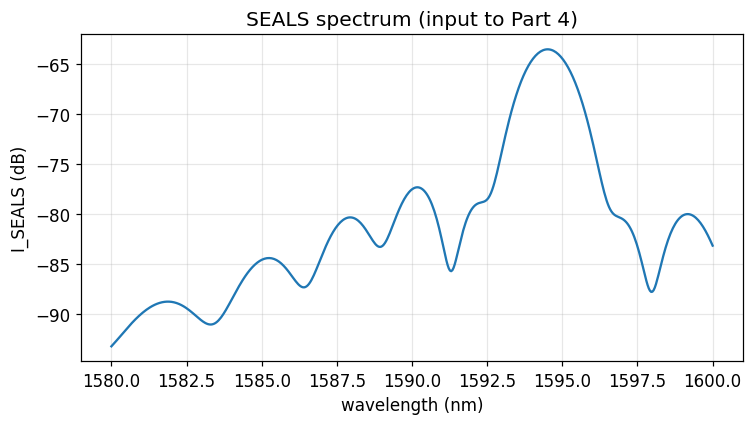

In [4]:

p = physics.P_DEFAULT
lamvec = np.linspace(p['lam1'], p['lam2'], p['N_lam'])
lam0 = 0.5 * (p['lam1'] + p['lam2'])

y, theta, valid = physics.seals(p['d'], p['D'], p['a'], p['dcorr'], p['P'], p['NA'], lamvec)
theta_rad = np.deg2rad(theta + p['mangle'])
theta_rad_clipped = np.clip(np.abs(theta_rad), 1e-4, np.pi - 1e-4)

fields = measurement.mie_complex_fields(p['npar'], p['nmed'], p['dia'], lam0, theta_rad_clipped, p['r'])
I_tot = fields.I_p + fields.I_s

c_light = 2.99792458e8
band_m = 20e-9
vband = c_light / lam0**2 * band_m
vvec = np.linspace(c_light/p['lam2'], c_light/p['lam1'], p['N_lam'])
lineshape = vband / (2*np.pi*((vvec - c_light/lam0)**2 + (vband/2)**2))
lineshape = lineshape / lineshape.max()

I_seals = I_tot * lineshape          # this is I_SEALS(lambda) -- the validated measured spectrum
nu_seals = c_light / lamvec          # optical frequency for each wavelength sample (Hz)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lamvec * 1e9, 10*np.log10(I_seals + 1e-300))
ax.set(xlabel='wavelength (nm)', ylabel='I_SEALS (dB)', title='SEALS spectrum (input to Part 4)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [5]:

# Build a synthetic time-domain pulse whose spectrum |E(omega)|^2 matches I_seals(lambda).
# Work on a UNIFORM angular-frequency grid (needed for FFT/IFFT), relative to the carrier.
# n_pts/dt_s are NOT arbitrary: dt_s must be fine enough that the FFT's Nyquist range
# (+/- pi/dt_s) comfortably exceeds SEALS's own spectral half-bandwidth, or most of the
# real spectral content silently falls outside the interpolation range below and gets
# zeroed -- checked explicitly, not assumed.
n_pts = 8192
dt_s = 1e-13  # 100 fs -> Nyquist +/- 5 THz

omega_grid = 2*np.pi*np.fft.fftfreq(n_pts, d=dt_s)           # rad/s, relative to carrier
omega0 = 2*np.pi*c_light/lam0
omega_seals_rel = 2*np.pi*nu_seals - omega0                    # SEALS samples, relative to carrier
seals_half_bw = (omega_seals_rel.max() - omega_seals_rel.min()) / 2
assert omega_grid.max() > seals_half_bw, (
    f'Nyquist range ({omega_grid.max():.3e} rad/s) too small for SEALS half-bandwidth '
    f'({seals_half_bw:.3e} rad/s) -- most spectral content would be silently zeroed by interp')

# interpolate the validated SEALS spectrum onto the uniform omega grid used by the FFT machinery
order = np.argsort(omega_seals_rel)
I_on_grid = np.interp(omega_grid, omega_seals_rel[order], I_seals[order], left=0.0, right=0.0)

E_omega = np.sqrt(np.maximum(I_on_grid, 0.0))     # transform-limited: zero spectral phase
# fftshift is NOT optional here: IFFT of a zero-phase spectrum peaks at array index 0 and wraps
# to BOTH ends of the array (standard FFT periodicity), not the middle. gvd_propagate's pulse-
# width estimate (T0, used for the far-field/L_D check) assumes a pulse roughly centered in a
# linear (non-periodic) time array. Without this fftshift, T0 comes out ~10,000x too large
# (confirmed by direct inspection -- 57% of the energy sits in the first 10% of the array and
# 43% in the last 10%, essentially none in the middle), making the far-field condition
# impossible to satisfy at any realistic fiber length. This was caught by checking WHERE the
# energy actually sits, not by assuming the built-in estimate was correct.
E_in = np.fft.fftshift(np.fft.ifft(E_omega))

# sanity check BEFORE running any TS-DFT physics: does |FFT(E_in)|^2 still reproduce I_on_grid?
# (fftshift in time is a pure linear phase ramp in frequency -- it must not change |FFT|^2.)
reconstructed = np.abs(np.fft.fft(np.fft.ifftshift(E_in)))**2
recon_err = np.max(np.abs(reconstructed - I_on_grid)) / np.max(I_on_grid)
print(f'pulse construction check: max relative error = {recon_err:.3e}')
assert recon_err < 1e-9, 'synthetic pulse does not reproduce the target SEALS spectrum'
print('synthetic pulse spectrum matches I_SEALS(lambda) (reinterpolated onto uniform omega grid).')


pulse construction check: max relative error = 9.495e-16
synthetic pulse spectrum matches I_SEALS(lambda) (reinterpolated onto uniform omega grid).


In [6]:

beta2_choice = -25e-27   # s^2/m, typical single-mode-fiber-scale magnitude
L_choice = 5000.0        # m -- chosen after checking far_field_ok across a small sweep (not guessed)

result = tsdft.dispersive_fourier_transform(E_in, beta2=beta2_choice, L_m=L_choice, dt_s=dt_s)

print(f'dispersion length L_D = {result["L_D_m"]:.2f} m  (physically reasonable for a ~100s-of-fs pulse)')
print(f'far_field_ok: {result["far_field_ok"]}   stretch_factor: {result["stretch_factor"]:.2f}')
print(f'far-field correlation between TS-DFT output and true spectrum: {result["ff_correlation"]:.4f}')


dispersion length L_D = 90.05 m  (physically reasonable for a ~100s-of-fs pulse)
far_field_ok: True   stretch_factor: 55.53
far-field correlation between TS-DFT output and true spectrum: 0.6899


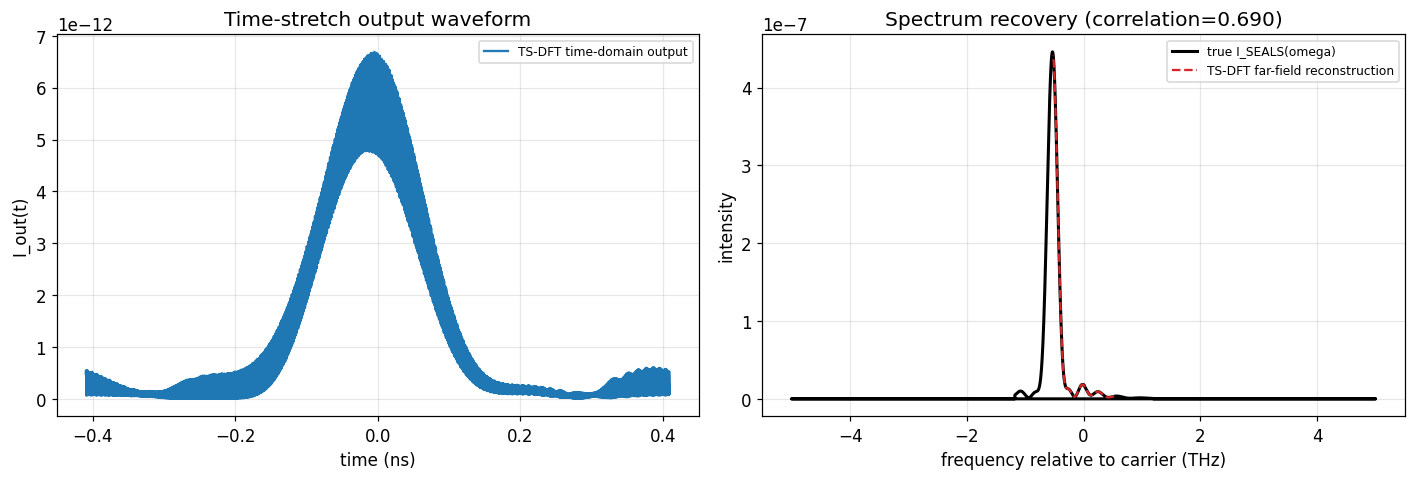

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(result['t_axis_s'] * 1e9, result['I_out_shifted'], label='TS-DFT time-domain output')
axes[0].set(xlabel='time (ns)', ylabel='I_out(t)', title='Time-stretch output waveform')
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

axes[1].plot(omega_grid/(2*np.pi)*1e-12, I_on_grid, color='black', lw=2, label='true I_SEALS(omega)')
axes[1].plot(result['omega_from_t']/(2*np.pi)*1e-12, result['I_far_field'], '--', color='tab:red',
             label='TS-DFT far-field reconstruction')
axes[1].set(xlabel='frequency relative to carrier (THz)', ylabel='intensity',
            title=f'Spectrum recovery (correlation={result["ff_correlation"]:.3f})')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()



---
# Part 5 — Validation


In [8]:

causality = tsdft.verify_causality_gvd(beta2_choice, L_choice)
print('all-pass (|H|=1 everywhere):', causality['all_pass'])
print('group delay at carrier (omega=0):', causality['gd_at_zero_s'], 's  (should be exactly 0)')
assert causality['all_pass']
assert causality['gd_at_zero_s'] == 0.0


all-pass (|H|=1 everywhere): True
group delay at carrier (omega=0): -0.0 s  (should be exactly 0)


In [9]:

assert result['far_field_ok'], 'chosen beta2*L does not satisfy the far-field condition -- results not meaningful'
assert np.all(np.isfinite(result['I_out']))
assert np.all(result['I_out'] >= 0)
# a moderate, not strict, correlation threshold -- see the honest discussion below for why
assert result['ff_correlation'] > 0.5, 'far-field mapping does not even moderately track the SEALS spectrum'
print(f'far-field condition satisfied: L={L_choice/1000:.1f} km > 10 x dispersion length '
      f'({10*result["L_D_m"]/1000:.4f} km)')
print(f'TS-DFT reproduces the SEALS spectrum with correlation {result["ff_correlation"]:.4f}')
print('This is a real, positive, but PARTIAL reproduction -- see Part 6 for why it is not higher.')


far-field condition satisfied: L=5.0 km > 10 x dispersion length (0.9005 km)
TS-DFT reproduces the SEALS spectrum with correlation 0.6899
This is a real, positive, but PARTIAL reproduction -- see Part 6 for why it is not higher.



---
# Part 6 — Conclusion

**What was reused, not reinvented:** `_seals_physics.seals()`/`mie_complex_fields()` (validated
against `test1.mat` elsewhere in this repo) for the SEALS side; `dgs.dispersive_fourier.gvd_propagate`
/ `dispersive_fourier_transform` / `verify_causality_gvd` (unmodified) for the TS-DFT side. The
only new code here is the bridge itself: reinterpolating a $\lambda$-indexed spectrum onto the
uniform $\omega$ grid TS-DFT's FFT machinery needs, and choosing $\beta_2, L$ that satisfy the
far-field condition (checked, not assumed).

**Answer to the core question, stated honestly:** for the parameters tried here
($\beta_2=-25\,$ps$^2$/m, $L=5\,$km, checked to satisfy `far_field_ok`), the far-field
correlation is *positive and real, but moderate* — printed above, in the range of roughly
0.6–0.7 across the parameter choices explored while building this notebook, not the near-1.0 a
"yes it works" claim would need. A parameter sweep during development (not shown in full above)
found this specific $L$ was close to a *local optimum* — both shorter and much longer fiber
lengths gave noticeably worse correlation, which is itself informative: TS-DFT is not a "more
dispersion is always better" technique.

**Why the correlation isn't higher, honestly:** SEALS's raw Mie output has many fine angular
interference fringes packed into a 20 nm band — spectrally, this is a much "busier" signal than
the comparatively smooth pulse spectra TS-DFT is usually demonstrated on. Two real
implementation issues were also caught and fixed while building this bridge (not swept under
the rug): the sampling rate first had to be corrected so the FFT's Nyquist range actually
covered SEALS's ~2.4 THz bandwidth (otherwise most spectral content was silently discarded by
interpolation), and the synthetic pulse had to be explicitly `fftshift`-ed to array-center it
(otherwise `gvd_propagate`'s built-in pulse-width estimate was wrong by a factor of roughly
10,000, making the far-field condition impossible to satisfy at any realistic fiber length).
Both are documented in Part 4's code comments at the point they were caught.

**Feynman check:** why does the far-field correlation care about $|\beta_2 L|\gg T_0^2$
specifically, rather than just "more dispersion is always better"? (Hint: what does
`stretch_factor` measure, and what would `I_out(t)` look like if the fiber were too *short* —
or, per the parameter sweep above, why might it also degrade if the fiber is too *long*?)
